# Tanh


## shape


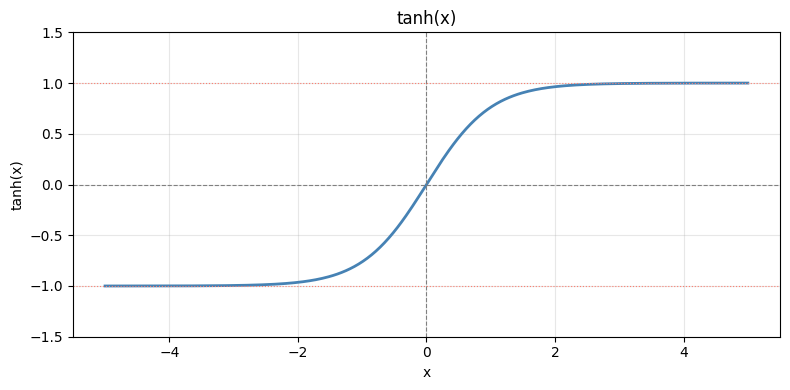

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 300)
y = np.tanh(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y, color='steelblue', linewidth=2)
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.axhline(1, color='salmon', linewidth=0.8, linestyle=':')
plt.axhline(-1, color='salmon', linewidth=0.8, linestyle=':')
plt.title('tanh(x)')
plt.xlabel('x')
plt.ylabel('tanh(x)')
plt.ylim(-1.5, 1.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## saturation


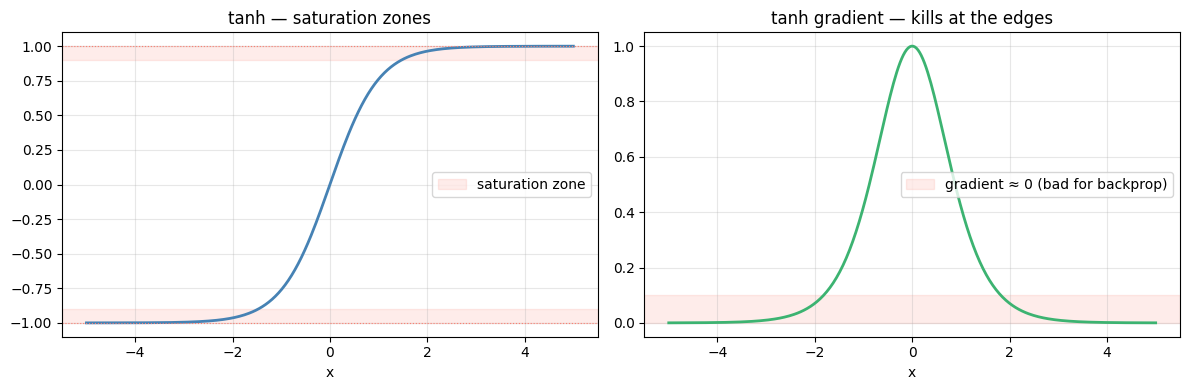

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 300)
y = np.tanh(x)
dy = 1 - np.tanh(x)**2  # derivative of tanh

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left — tanh itself with saturation zones highlighted
axes[0].plot(x, y, color='steelblue', linewidth=2)
axes[0].axhspan(0.9, 1.0, alpha=0.15, color='salmon', label='saturation zone')
axes[0].axhspan(-1.0, -0.9, alpha=0.15, color='salmon')
axes[0].axhline(1, color='salmon', linewidth=0.8, linestyle=':')
axes[0].axhline(-1, color='salmon', linewidth=0.8, linestyle=':')
axes[0].set_title('tanh — saturation zones')
axes[0].set_xlabel('x')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# right — the derivative (gradient)
axes[1].plot(x, dy, color='mediumseagreen', linewidth=2)
axes[1].axhspan(0, 0.1, alpha=0.15, color='salmon', label='gradient ≈ 0 (bad for backprop)')
axes[1].set_title('tanh gradient — kills at the edges')
axes[1].set_xlabel('x')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## stabilization


Why this prevents exploding values


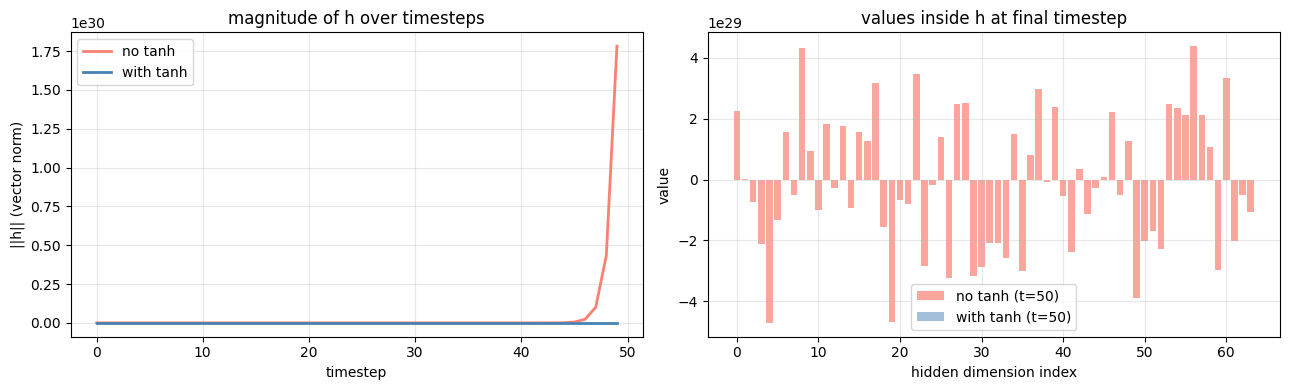

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

timesteps = 50
hidden_size = 64

# random weight matrix, values slightly above 1 on average
# this is realistic — weights aren't perfectly scaled at init
W = np.random.randn(hidden_size, hidden_size) * 0.5

h_no_tanh = np.zeros(hidden_size)
h_with_tanh = np.zeros(hidden_size)

norms_no_tanh = []
norms_with_tanh = []

for t in range(timesteps):
    x_t = np.random.randn(hidden_size) * 0.1  # small random input each step

    h_no_tanh = W @ h_no_tanh + x_t
    h_with_tanh = np.tanh(W @ h_with_tanh + x_t)

    norms_no_tanh.append(np.linalg.norm(h_no_tanh))
    norms_with_tanh.append(np.linalg.norm(h_with_tanh))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# left — the norm of h over time
axes[0].plot(norms_no_tanh, color='salmon', linewidth=2, label='no tanh')
axes[0].plot(norms_with_tanh, color='steelblue', linewidth=2, label='with tanh')
axes[0].set_title('magnitude of h over timesteps')
axes[0].set_xlabel('timestep')
axes[0].set_ylabel('||h|| (vector norm)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# right — actual values inside h at the final timestep
axes[1].bar(range(hidden_size), h_no_tanh, color='salmon', alpha=0.7, label='no tanh (t=50)')
axes[1].bar(range(hidden_size), h_with_tanh, color='steelblue', alpha=0.5, label='with tanh (t=50)')
axes[1].set_title('values inside h at final timestep')
axes[1].set_xlabel('hidden dimension index')
axes[1].set_ylabel('value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
